# Exhibit: The Phillips Curve

*Workshop 2 exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The relation

The **Phillips curve** — the relationship between inflation and unemployment — is arguably the most policy-relevant empirical relation in macroeconomics: every central bank's view of the inflation–activity trade-off runs through some version of it. In its expectations-augmented form, inflation depends on economic slack and on expected (here: past) inflation:

$$\pi_t = c + \lambda \, u_t + \varphi \, \pi_{t-1} + \text{error}_t,$$

where $\pi_t$ is CPI inflation (year-over-year, %), $u_t$ the unemployment rate, and $\lambda$ — the **slope** — measures how much slack disciplines inflation. A central bank that believes $\lambda$ is large expects unemployment to bring inflation down quickly; one that believes $\lambda \approx 0$ (a "flat" Phillips curve) does not.

Whether the slope has *changed* is one of the liveliest debates in macroeconomics: the curve seemed to flatten dramatically during the Great Moderation (Del Negro et al. 2020; Hazell et al. 2022), and the post-2020 inflation surge reopened the question. Section 5+ of the Coibion–Gorodnichenko–Kamdar paper you are reading is precisely about the role of expectations in this relation.

**Data:** quarterly US data, 1960–2025 — CPI inflation and the unemployment rate (FRED: CPIAUCSL, UNRATE).

**A deliberate simplification — read before you build on this.** The specification above is a *starting point, not a finished specification*: it replaces expected inflation with **lagged inflation** (a backward-looking proxy), uses the raw unemployment rate instead of a measure of slack (an unemployment *gap* relative to its natural rate), and includes no supply-side controls (energy and import prices). Good enough to see the stability question — not good enough to be the specification in your paper. Upgrading the simplification that matters for your question is part of the work, and often part of the contribution: for instance, replacing lagged inflation with **survey expectations** (the SPF forecasts from the forecast-errors exhibit) turns this into the expectations-augmented Phillips curve that Section 5 of your Coibion–Gorodnichenko–Kamdar reading is about.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="quarter")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="quarter")
    df.index = pd.PeriodIndex(df.index, freq="Q")
    return df

pc = load("phillips_curve.csv").loc[:"2025Q4"].dropna()
pc.tail(3)

,inflation,unemployment,inflation_lag
quarter,,,
2025Q2,2.6805,4.2000,2.3820
2025Q3,3.0226,4.3333,2.6805
2025Q4,2.6533,4.4500,3.0226


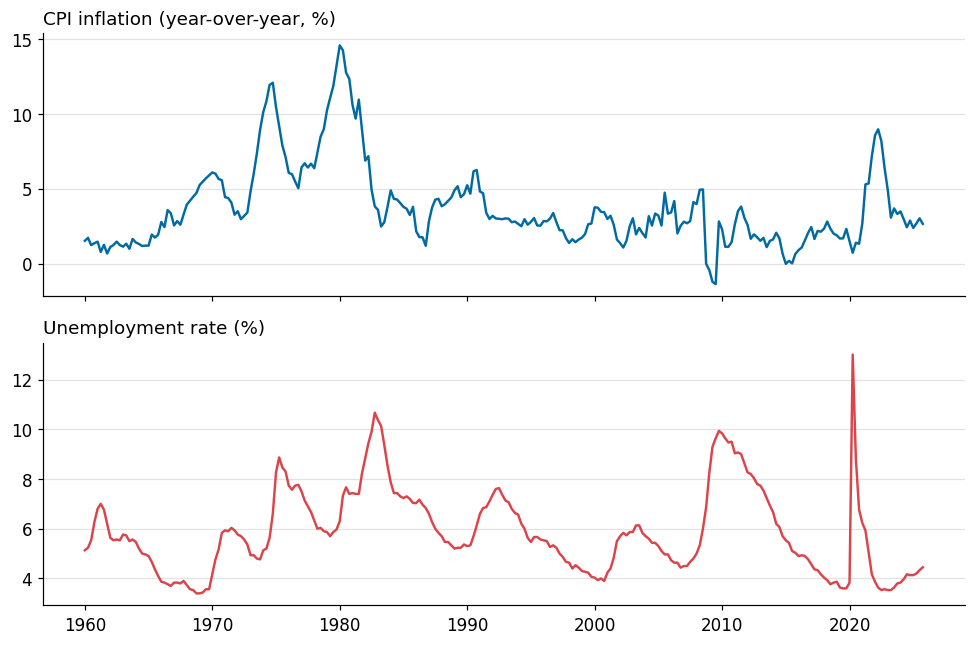

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
x = pc.index.to_timestamp()
axes[0].plot(x, pc["inflation"], color=BLUE, lw=1.6)
axes[0].set_title("CPI inflation (year-over-year, %)")
axes[1].plot(x, pc["unemployment"], color=RED, lw=1.6)
axes[1].set_title("Unemployment rate (%)")
plt.tight_layout()
plt.show()

## 2. The full-sample estimate

Estimate the Phillips curve over the whole sample, 1960–2025, with HAC standard errors. The coefficient to watch is the **slope** on unemployment.

In [3]:
def fit_pc(d):
    y = d["inflation"]
    X = sm.add_constant(d[["unemployment", "inflation_lag"]])
    return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

full = fit_pc(pc)
print(f"Sample: {pc.index.min()}–{pc.index.max()}  (n = {int(full.nobs)})")
print(full.summary().tables[1])

Sample: 1960Q1–2025Q4  (n = 264)
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6029      0.216      2.795      0.005       0.180       1.026
unemployment     -0.0748      0.039     -1.929      0.054      -0.151       0.001
inflation_lag     0.9572      0.033     29.200      0.000       0.893       1.021


The full-sample slope is small and negative — about $-0.07$: a one-point rise in unemployment lowers inflation by less than a tenth of a percentage point, controlling for lagged inflation. Most of the action is in the lagged-inflation coefficient near one — inflation is highly persistent.

**Is this one relationship — or an average over several different ones?**

## 3. Is it stable? Your turn first

Below is a set of subsamples corresponding to well-known macroeconomic eras. Run it — then **change the splits** (edit the dictionary, rerun) and see what happens to the slope. Where would *you* cut the sample, and why?

In [4]:
SUBSAMPLES = {
    "Pre-1973":            ("1960Q1", "1972Q4"),
    "Great Inflation":     ("1973Q1", "1984Q4"),
    "Great Moderation":    ("1985Q1", "2019Q4"),
    "Post-2020":           ("2020Q1", "2025Q4"),
}

rows = []
for name, (start, end) in SUBSAMPLES.items():
    r = fit_pc(pc.loc[start:end])
    rows.append({"sample": name,
                 "slope": r.params["unemployment"], "se(slope)": r.bse["unemployment"],
                 "p(slope)": r.pvalues["unemployment"],
                 "lag coef": r.params["inflation_lag"], "n": int(r.nobs)})
pd.DataFrame(rows).round(3)

,sample,slope,se(slope),p(slope),lag coef,n
0,Pre-1973,-0.221,0.039,0.000,0.907,52
1,Great Inflation,-0.546,0.063,0.000,0.878,48
2,Great Moderation,-0.043,0.044,0.326,0.788,140
3,Post-2020,-0.000,0.076,0.998,0.892,24


### Now compare with a formal test

Choosing split dates yourself is a start — but *you* chose them, knowing the history. A formal structural-break test (**Bai–Perron**) lets the *data* choose the break dates. How it works is the topic of Workshop 3; here is what it finds for this regression:

**Estimated break dates: 1973Q1, 1981Q4, 2002Q4, 2009Q4, 2016Q3** — six regimes.

How close were your splits? Notice the test agrees with history on the Great Inflation's start (1973) and the Volcker disinflation (1981) — but also finds breaks you may not have guessed (2002, 2009, 2016).

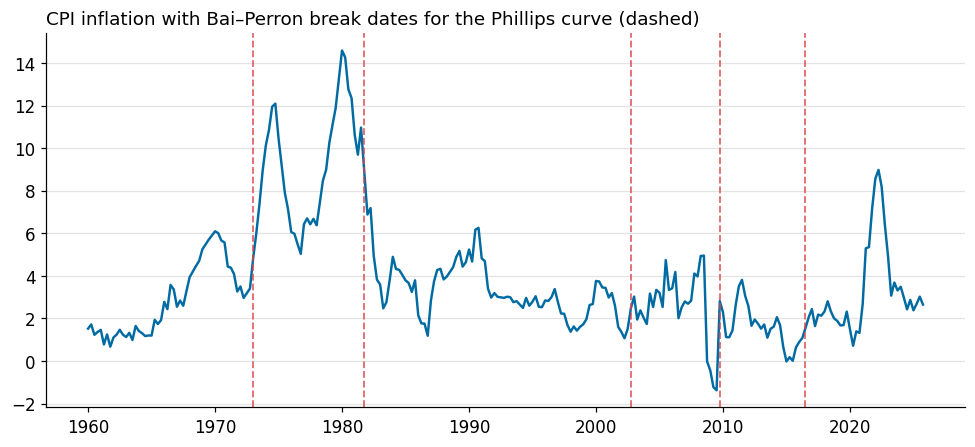

In [5]:
BP_BREAKS = ["1973Q1", "1981Q4", "2002Q4", "2009Q4", "2016Q3"]  # Bai-Perron, precomputed

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(pc.index.to_timestamp(), pc["inflation"], color=BLUE, lw=1.6)
for b in BP_BREAKS:
    ax.axvline(pd.Period(b, freq="Q").to_timestamp(), color=RED, lw=1.2, ls="--", alpha=0.8)
ax.set_title("CPI inflation with Bai–Perron break dates for the Phillips curve (dashed)")
plt.tight_layout()
plt.show()

### Try the regime estimates yourself

Given the break dates, the regime-by-regime estimates are just **subsample estimates with the splits placed at the estimated dates**. The next cell runs exactly that – **just run it.**

Which regimes show a steep slope, which a flat one – and where does the post-2020 surge land? One caution: the middle regimes are only 26–28 quarters long, so watch the standard errors. How the data *chooses* these dates is Workshop 3.

In [6]:
# Regime-by-regime estimates: subsample estimates with the splits at the Bai-Perron dates
REGIMES = {
    "1960Q1–1972Q4": ("1960Q1", "1972Q4"),
    "1973Q1–1981Q3": ("1973Q1", "1981Q3"),
    "1981Q4–2002Q3": ("1981Q4", "2002Q3"),
    "2002Q4–2009Q3": ("2002Q4", "2009Q3"),
    "2009Q4–2016Q2": ("2009Q4", "2016Q2"),
    "2016Q3–2025Q4": ("2016Q3", "2025Q4"),
}

rows = []
for name, (start, end) in REGIMES.items():
    r = fit_pc(pc.loc[start:end])
    rows.append({"regime": name,
                 "slope": r.params["unemployment"], "se(slope)": r.bse["unemployment"],
                 "p(slope)": r.pvalues["unemployment"],
                 "lag coef": r.params["inflation_lag"], "n": int(r.nobs)})
pd.DataFrame(rows).round(3)

,regime,slope,se(slope),p(slope),lag coef,n
0,1960Q1–1972Q4,-0.221,0.039,0.000,0.907,52
1,1973Q1–1981Q3,-0.696,0.079,0.000,0.950,35
2,1981Q4–2002Q3,-0.058,0.047,0.222,0.810,84
3,2002Q4–2009Q3,-0.820,0.198,0.000,0.221,28
4,2009Q4–2016Q2,0.312,0.090,0.001,0.304,27
5,2016Q3–2025Q4,0.018,0.086,0.831,0.903,38


## 4. What could a paper deliver?

You have now seen that the relation is not stable. **That, by itself, is not yet a research question.** "Is X stable? — No" is a finding, not a paper. The interesting paper starts with what you build *on top of* the finding. Four types of questions you can build:

1. **Timing / episodes** — do the shifts line up with identifiable economic history? (Oil shocks, Volcker, the financial crisis, COVID…) What happened at 2002Q4 or 2016Q3?
2. **Source / mechanism** — *what* changed: the slope, the persistence, the role of expectations? Did monetary policy itself change the relation (a Lucas-critique story)?
3. **Interpretation / inference** — what does instability do to the tools? What is a full-sample Phillips-curve estimate even measuring, if the slope moves? What does it mean for the "flattening" debate?
4. **Consequences / practice** — what does it mean for those who *use* the relation? If a central bank's model assumes yesterday's slope, what happens to its inflation forecasts — say, in 2021?

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*. Compare (on a relation that is *not* one of today's exhibits):

> *Weak:* "This paper examines whether Okun's law is stable."
>
> *Strong:* "This paper shows that Okun's law held in every US recession since 1960 except 2020, and asks what made the COVID labor market different."

The strong version states a deliverable and why it is interesting — even before the analysis exists.

**Your task (in class):** write one or two **"This paper…"** sentences for this exhibit. Be specific: what does your paper show, ask, or deliver?

## 5. Further reading

If this exhibit grabbed you, start here:

- Coibion, O., Gorodnichenko, Y., and Kamdar, R. (2018). "The Formation of Expectations, Inflation, and the Phillips Curve." *Journal of Economic Literature*, 56(4) — **Section 5 onward**: the expectations side of the Phillips curve (you already have this paper).
- Hazell, J., Herreño, J., Nakamura, E., and Steinsson, J. (2022). "The Slope of the Phillips Curve: Evidence from U.S. States." *Quarterly Journal of Economics*, 137(3) — the modern benchmark on measuring the slope.
- Del Negro, M., Lenza, M., Primiceri, G., and Tambalotti, A. (2020). "What's Up with the Phillips Curve?" *Brookings Papers on Economic Activity* — the flattening debate, pre-COVID.
- Staiger, D., Stock, J. H., and Watson, M. W. (1997). "The NAIRU, Unemployment and Monetary Policy." *Journal of Economic Perspectives*, 11(1) — how imprecisely the "natural rate" is measured.
- Stock, J. H., and Watson, M. W. (2007). "Why Has U.S. Inflation Become Harder to Forecast?" *Journal of Money, Credit and Banking*, 39(s1) — changing inflation dynamics as time variation.